In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

In [ ]:
df = pd.read_csv("HIV_dataset.csv")

# EDA

In [ ]:
df.head()

,Age,Marital Staus,STD,Educational Background,HIV TEST IN PAST YEAR,AIDS education,Places of seeking sex partners,SEXUAL ORIENTATION,Drug- taking,Result
0,22,UNMARRIED,NO,College Degree,YES,NO,Bar,Heterosexual,YES,POSITIVE
1,20,UNMARRIED,NO,College Degree,NO,YES,NaN,Heterosexual,NO,NEGATIVE
2,23,Married,YES,College Degree,NO,YES,NaN,Bisexual,NO,NEGATIVE
3,24,Married,NO,College Degree,YES,YES,Park,Heterosexual,YES,POSITIVE
4,18,UNMARRIED,YES,Senior High School,YES,NO,Internet,Heterosexual,YES,POSITIVE


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 698 entries, 0 to 697
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Age                             698 non-null    int64 
 1   Marital Staus                   698 non-null    object
 2   STD                             698 non-null    object
 3   Educational Background          698 non-null    object
 4   HIV TEST IN PAST YEAR           698 non-null    object
 5   AIDS education                  698 non-null    object
 6   Places of seeking sex partners  676 non-null    object
 7   SEXUAL ORIENTATION              698 non-null    object
 8   Drug- taking                    698 non-null    object
 9   Result                          698 non-null    object
dtypes: int64(1), object(9)
memory usage: 54.7+ KB


In [ ]:
df = df.rename(columns={'Marital Staus': 'Marital Status'})
replace_dict = {'UNMARRIED': 'Unmarried', 'MARRIED': 'Married', 'DIvorced': 'Divorced'}
df['Marital Status'] = df['Marital Status'].replace(replace_dict)
df['Marital Status'].value_counts()

,count
Marital Status,
Unmarried,276
Married,202
Divorced,102
Widowed,82
Cohabiting,36


In [ ]:
replace_dict = {'NO': 'No', 'YES': 'Yes'}
df['STD'] = df['STD'].replace(replace_dict)
df['STD'].value_counts()

,count
STD,
No,371
Yes,327


In [ ]:
replace_dict = {'College Dregree': 'College Degree'}
df['Educational Background'] = df['Educational Background'].replace(replace_dict)
df['Educational Background'].value_counts()

,count
Educational Background,
College Degree,238
Senior High School,136
Junior High School,136
Illiteracy,108
Primary School,80


In [ ]:
replace_dict = {'NO': 'No', 'YES': 'Yes'}
df['AIDS education'] = df['AIDS education'].replace(replace_dict)
df['AIDS education'].value_counts()

,count
AIDS education,
No,413
Yes,285


In [ ]:
replace_dict = {'Public bath': 'Public Bath'}
df['Places of seeking sex partners'] = df['Places of seeking sex partners'].replace(replace_dict)
df['Places of seeking sex partners'].value_counts()

,count
Places of seeking sex partners,
Internet,200
Bar,150
Public Bath,144
Park,108
Others,74


In [ ]:
replace_dict = {'Hetersexual': 'Heterosexual', 'BIsexual':'Bisexual'}
df['SEXUAL ORIENTATION'] = df['SEXUAL ORIENTATION'].replace(replace_dict)
df['SEXUAL ORIENTATION'].value_counts()

,count
SEXUAL ORIENTATION,
Heterosexual,374
Homosexual,174
Bisexual,150


In [ ]:
df = df.rename(columns={'Drug- taking': 'Drug-taking'})
replace_dict = {'NO': 'No', 'YES': 'Yes'}
df['Drug-taking'] = df['Drug-taking'].replace(replace_dict)
df['Drug-taking'].value_counts()

,count
Drug-taking,
No,401
Yes,297


In [ ]:
replace_dict = {'NEGATIVE': 'Negative', 'POSITIVE': 'Positive'}
df['Result'] = df['Result'].replace(replace_dict)
df['Result'].value_counts()

,count
Result,
Negative,352
Positive,346


In [ ]:
#### NOTE: -0.5 < x < 0.5 is a good skewness ####
num_features = df.select_dtypes(include= ["number"])
print(num_features.skew())

Age    0.439505
dtype: float64


array([[<Axes: title={'center': 'Age'}>]], dtype=object)

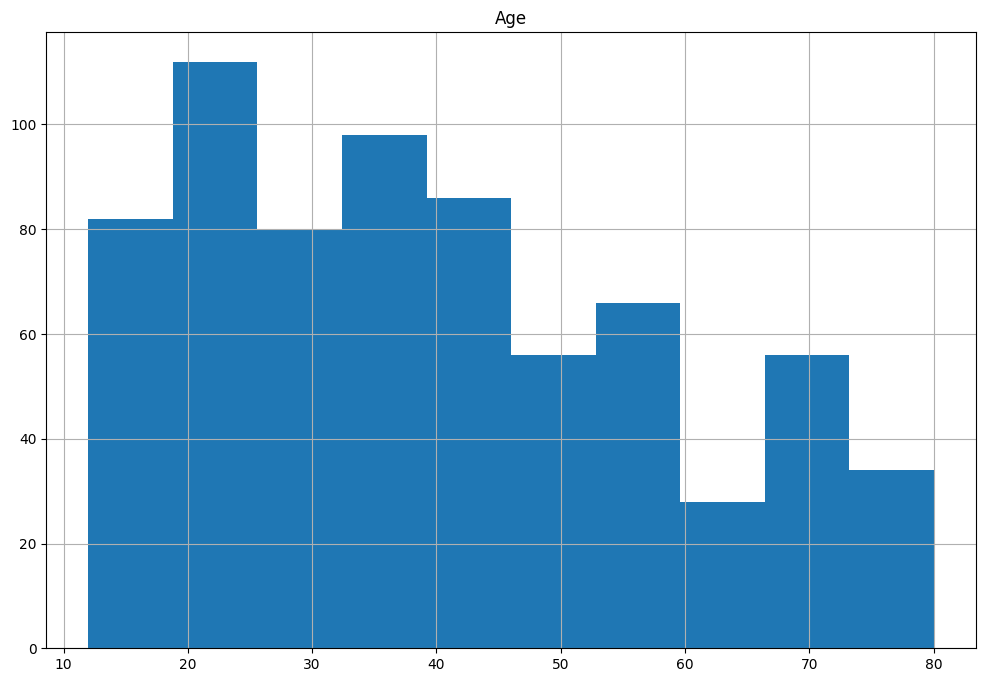

In [ ]:
df.hist(figsize=(12,8))

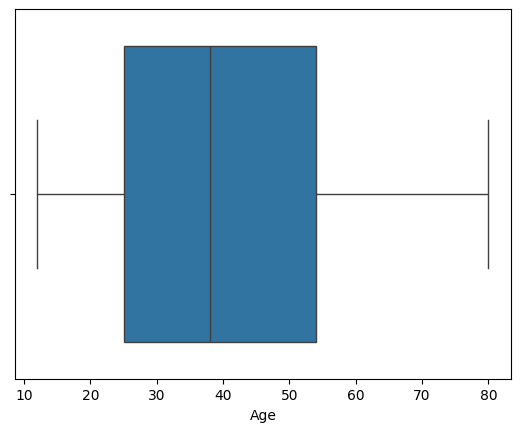

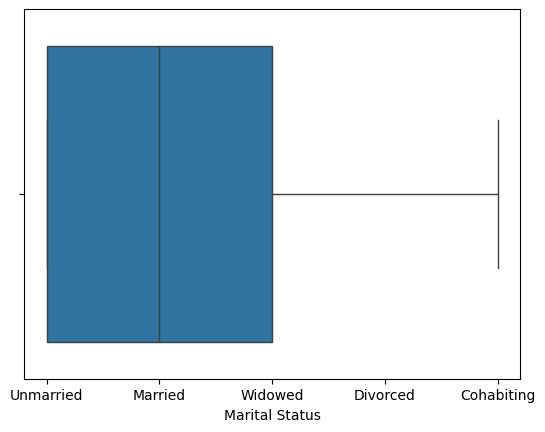

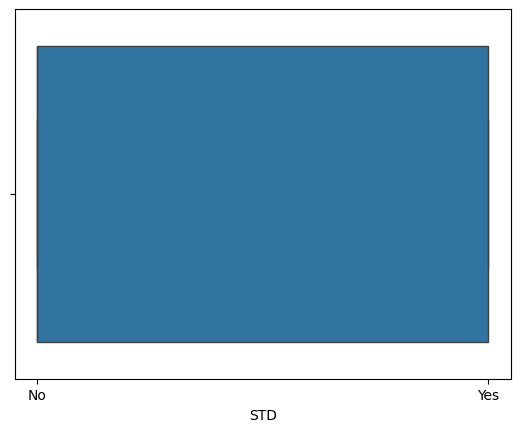

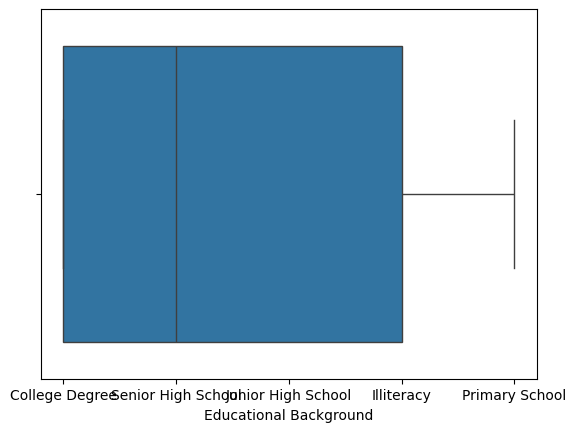

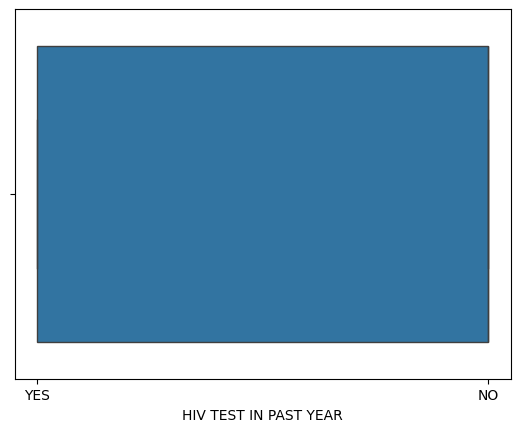

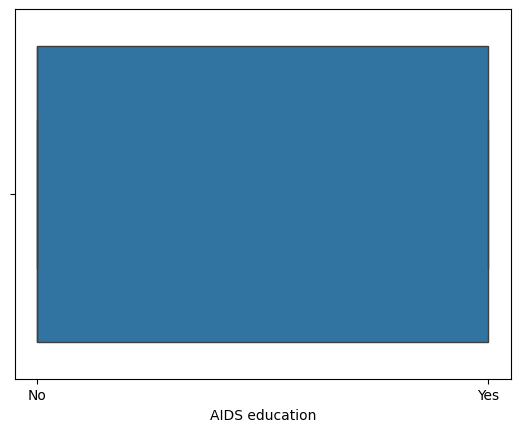

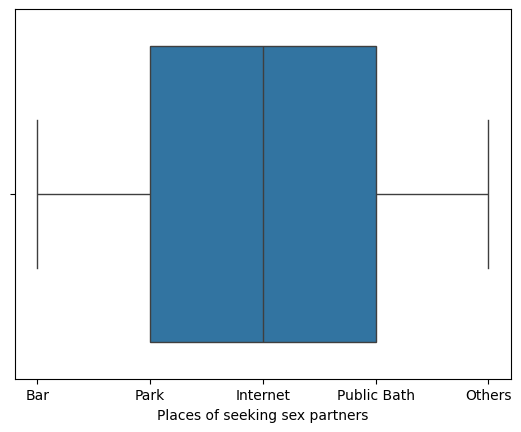

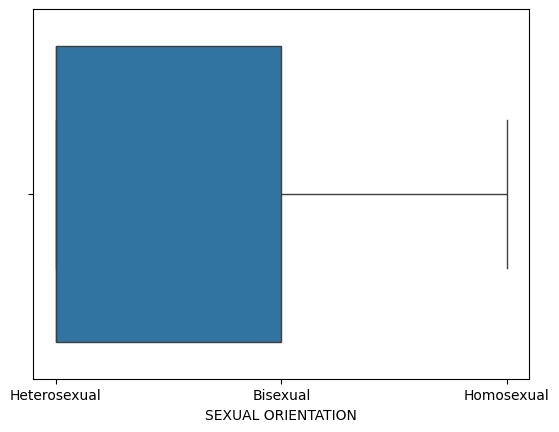

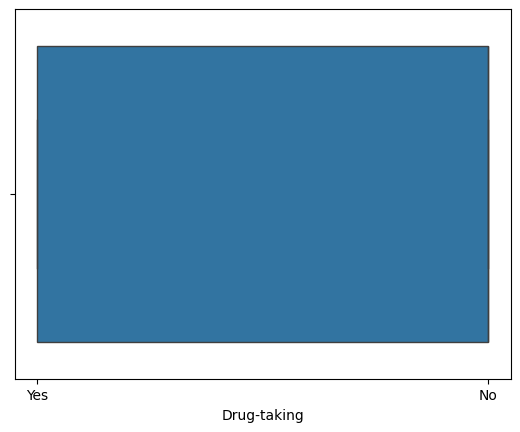

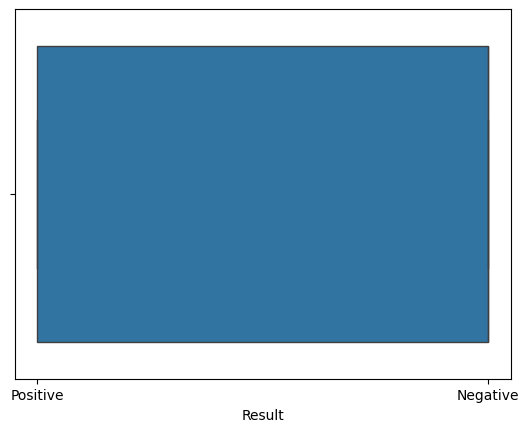

In [ ]:
for column in df.columns:
  sb.boxplot(data=df, x=column)
  plt.show()

## Data Preprocessing

In [ ]:
num_features = list(df.select_dtypes('number'))
nom_features = list(df.select_dtypes('object'))
nom_features.remove('Result')

In [ ]:
from sklearn.model_selection import train_test_split
X = df.drop("Result", axis=1)
y = df['Result']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size  = 0.2, random_state = 42)

In [ ]:
X_train.head()

,Age,Marital Status,STD,Educational Background,HIV TEST IN PAST YEAR,AIDS education,Places of seeking sex partners,SEXUAL ORIENTATION,Drug-taking
82,34,Unmarried,No,College Degree,NO,Yes,Bar,Bisexual,No
51,37,Divorced,No,Junior High School,NO,No,Internet,Bisexual,No
220,75,Married,Yes,Illiteracy,NO,No,Bar,Heterosexual,Yes
559,75,Married,No,Senior High School,YES,No,Park,Bisexual,No
544,54,Unmarried,No,College Degree,NO,Yes,NaN,Heterosexual,Yes


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder

from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

In [ ]:
num_pipeline = make_pipeline(
                             StandardScaler()
                            )

nom_pipeline = make_pipeline(
                             OneHotEncoder(handle_unknown='ignore')
                            )

preprocessor = ColumnTransformer([
                                  ('numerical', num_pipeline, num_features),
                                  ('nominal', nom_pipeline, nom_features),
                                ])
preprocessor.fit(X_train)

ColumnTransformer(transformers=[('numerical',
                                 Pipeline(steps=[('standardscaler',
                                                  StandardScaler())]),
                                 ['Age']),
                                ('nominal',
                                 Pipeline(steps=[('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Marital Status', 'STD',
                                  'Educational Background',
                                  'HIV TEST IN PAST YEAR', 'AIDS education',
                                  'Places of seeking sex partners',
                                  'SEXUAL ORIENTATION', 'Drug-taking'])])

In [ ]:
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [ ]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

# Base Models (Logistic Regression, Naive Bayes, Decision Tree, SVM)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

models_and_grids = {
    'Logistic Regression': {
        'pipeline': Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', LogisticRegression(random_state=42, max_iter=1000))
        ]),
        'params': {
            'classifier__C': [0.01, 0.1, 1, 10],
            'classifier__penalty': ['l2'],
            'classifier__solver': ['lbfgs']
        }
    },
    'GaussianNB': {
        'pipeline': Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', GaussianNB())
        ]),
        'params': {
            'classifier__var_smoothing': [1e-9, 1e-8, 1e-7]
        }
    },
    'Decision Tree': {
        'pipeline': Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', DecisionTreeClassifier(random_state=42))
        ]),
        'params': {
            'classifier__max_depth': [None, 10, 20],
            'classifier__min_samples_split': [2, 5],
            'classifier__min_samples_leaf': [1, 2]
        }
    },
    'SVM': {
        'pipeline': Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', SVC(random_state=42))
        ]),
        'params': {
            'classifier__C': [0.1, 1, 10],
            'classifier__kernel': ['rbf', 'linear'],
            'classifier__gamma': ['scale', 'auto']
        }
    }
}

best_models = {}
for name, mg in models_and_grids.items():
    grid = GridSearchCV(mg['pipeline'], mg['params'], cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    best_models[name] = grid.best_estimator_
    print(f"Best params for {name}: {grid.best_params_}")
    preds = grid.predict(X_test)
    print(f"Classification Report for {name}:")
    print(classification_report(y_test, preds))

Best params for Logistic Regression: {'classifier__C': 0.01, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.74      0.94      0.83        65
           1       0.93      0.72      0.81        75

    accuracy                           0.82       140
   macro avg       0.84      0.83      0.82       140
weighted avg       0.84      0.82      0.82       140

Best params for GaussianNB: {'classifier__var_smoothing': 1e-09}
Classification Report for GaussianNB:
              precision    recall  f1-score   support

           0       0.72      0.77      0.75        65
           1       0.79      0.75      0.77        75

    accuracy                           0.76       140
   macro avg       0.76      0.76      0.76       140
weighted avg       0.76      0.76      0.76       140

Best params for Decision Tree: {'classifier__max_depth': None, 'classifier_

In [ ]:
best_lr = best_models['Logistic Regression'].named_steps['classifier']
best_nb = best_models['GaussianNB'].named_steps['classifier']
best_dt = best_models['Decision Tree'].named_steps['classifier']
best_svc = best_models['SVM'].named_steps['classifier']

# Uniform Ensemble (Random Forest & XGBoost)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(rf_pipeline, rf_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train, y_train)
rf_model = rf_grid.best_estimator_

import joblib
joblib.dump(rf_model, "rf_model.pkl")


xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))
])

xgb_param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 6, 10],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(xgb_pipeline, xgb_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
xgb_grid.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [02:51:56] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('standardscaler',
                                                                                          StandardScaler())]),
                                                                         ['Age']),
                                                                        ('nominal',
                                                                         Pipeline(steps=[('onehotencoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['Marital '
                                                                          'Status',
                                                                          'STD',
                                                                          'Educational '
                                                                          'Background',
                                                                          'HIV '
                                                                          'TEST '
                                                                          'IN '
                                                                          'PAST '
                                                                          'YEAR',
                                                                          'AIDS '
                                                                          'education'...
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None,
                                                      random_state=42, ...))]),
             n_jobs=-1,
             param_grid={'classifier__learning_rate': [0.01, 0.1, 0.2],
                         'classifier__max_depth': [3, 6, 10],
                         'classifier__n_estimators': [100, 200],
                         'classifier__subsample': [0.8, 1.0]},
             scoring='accuracy')

In [ ]:
rf_predictions = rf_grid.predict(X_test)
print("Classification Report for Random Forest:")
print(classification_report(y_test, rf_predictions))

xgb_predictions = xgb_grid.predict(X_test)
print("Classification Report for XGBoost:")
print(classification_report(y_test, xgb_predictions))

Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.98      0.95      0.97        65
           1       0.96      0.99      0.97        75

    accuracy                           0.97       140
   macro avg       0.97      0.97      0.97       140
weighted avg       0.97      0.97      0.97       140

Classification Report for XGBoost:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        65
           1       0.94      1.00      0.97        75

    accuracy                           0.96       140
   macro avg       0.97      0.96      0.96       140
weighted avg       0.97      0.96      0.96       140



# Stacked Ensemble

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

estimators = [
    ('lr', best_lr),
    ('nb', best_nb),
    ('dt', best_dt),
    ('svc', best_svc)
]

stacking_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', StackingClassifier(
        estimators=estimators,
        final_estimator=LogisticRegression(random_state=42),
        cv=5,
        passthrough=True
    ))
])

stack_param_grid = {
    'classifier__final_estimator__C': [0.01, 0.1, 1, 10],
    'classifier__final_estimator__penalty': ['l2'],
    'classifier__passthrough': [True, False]
}

stack_grid = GridSearchCV(
    stacking_pipeline,
    stack_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

stack_grid.fit(X_train, y_train)

print("Best parameters for Stacking Ensemble:", stack_grid.best_params_)

stack_preds = stack_grid.predict(X_test)
print("Classification Report for Tuned Stacking Ensemble:")
print(classification_report(y_test, stack_preds))

Best parameters for Stacking Ensemble: {'classifier__final_estimator__C': 0.01, 'classifier__final_estimator__penalty': 'l2', 'classifier__passthrough': False}
Classification Report for Tuned Stacking Ensemble:
              precision    recall  f1-score   support

           0       0.97      0.92      0.94        65
           1       0.94      0.97      0.95        75

    accuracy                           0.95       140
   macro avg       0.95      0.95      0.95       140
weighted avg       0.95      0.95      0.95       140



# SHAP

In [ ]:
import shap

explainer = shap.TreeExplainer(rf_model.named_steps['classifier'])

X_train_transformed_df = pd.DataFrame(X_train_transformed, columns=preprocessor.get_feature_names_out())

shap_values = explainer(X_train_transformed_df)

class_idx = 1

vals_2d = shap_values.values[:, :, class_idx]

if len(shap_values.base_values.shape) == 2:
    base_2d = shap_values.base_values[:, class_idx]
else:
    base_2d = shap_values.base_values

expl_2d = shap.Explanation(
    values=vals_2d,
    base_values=base_2d,
    data=X_train_transformed_df.values,
    feature_names=X_train_transformed_df.columns.tolist()
)

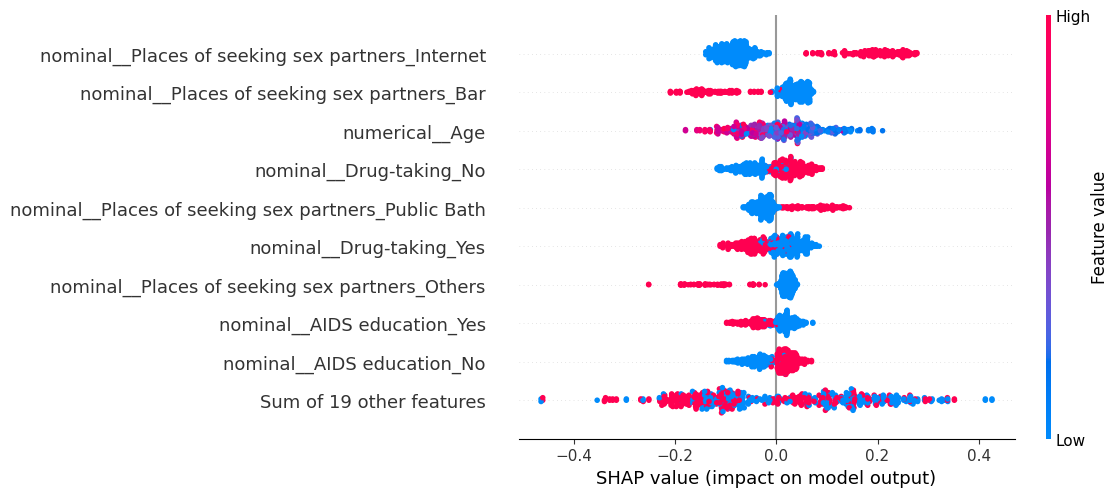

In [ ]:
# Beeswarm Plot
shap.plots.beeswarm(expl_2d)

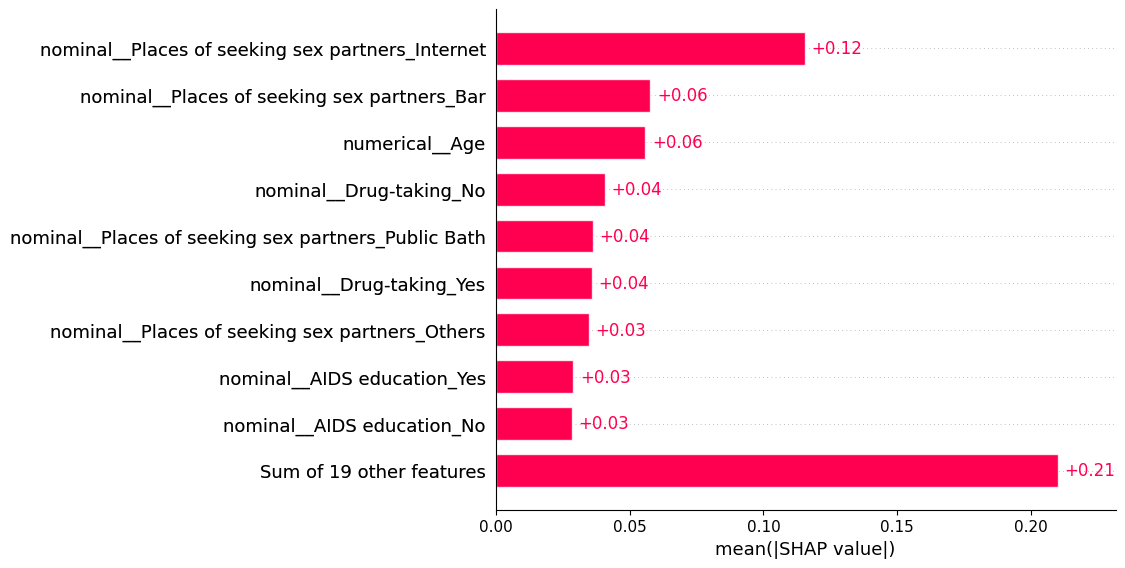

In [ ]:
# Absolute Mean SHAP
shap.plots.bar(expl_2d)

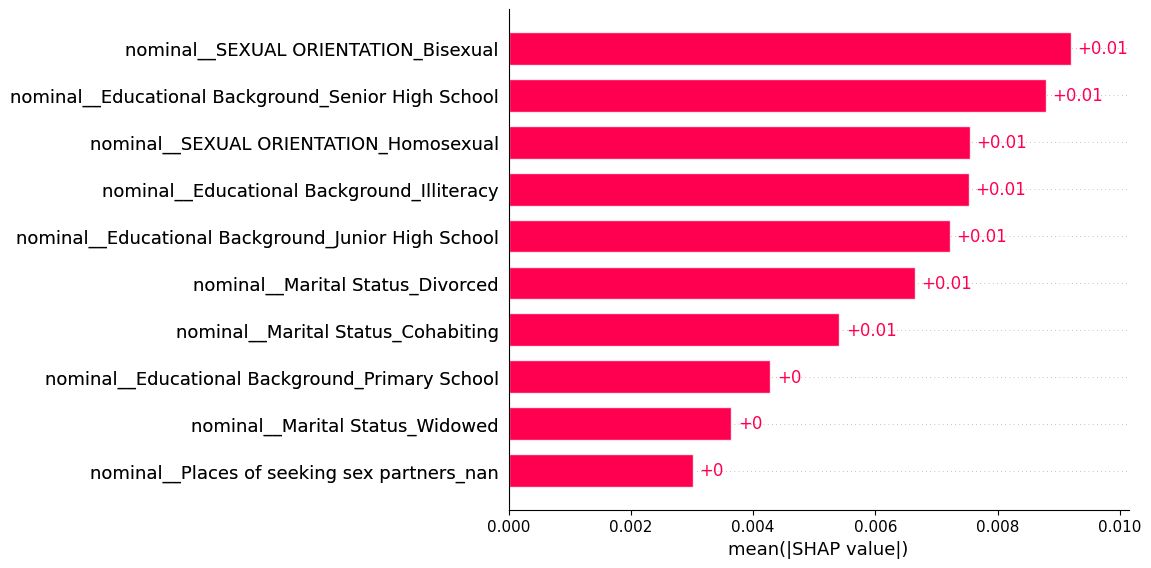

In [ ]:
# Absolute Mean SHAP for 10 lowest impact features
abs_shap_values = np.abs(expl_2d.values).mean(0)
feature_names = expl_2d.feature_names
shap_summary = pd.DataFrame({'feature': feature_names, 'mean_abs_shap': abs_shap_values})
lowest_impact_features = shap_summary.sort_values(by='mean_abs_shap', ascending=True).head(10)
lowest_impact_expl_2d = expl_2d[:, lowest_impact_features['feature'].tolist()]

shap.plots.bar(lowest_impact_expl_2d)

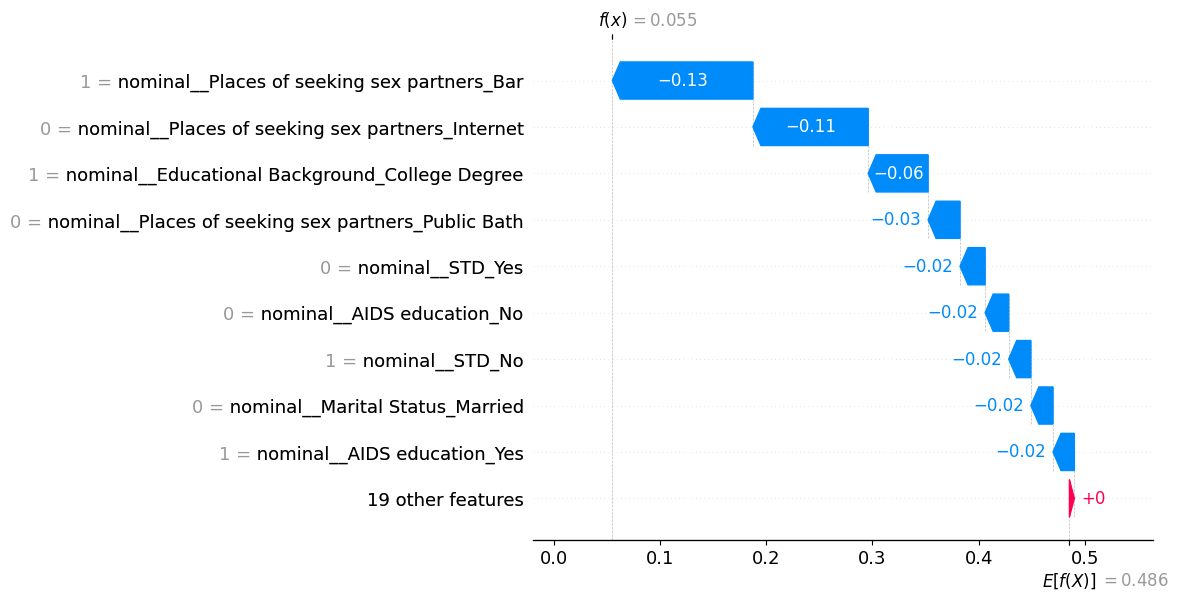

In [ ]:
# Waterfall Plot
sample_idx = 0
shap.plots.waterfall(expl_2d[sample_idx])

In [ ]:
import joblib
import gradio as gr

# Load your trained pipeline model (saved as a .pkl or .joblib file)
rf_model = joblib.load("rf_model.pkl")  # Make sure you've saved it after training

# Define the input feature names in correct order (match training data)
feature_names = [
    "Age", "Marital Status", "STD", "Educational Background", "HIV TEST IN PAST YEAR",
    "AIDS education", "Places of seeking sex partners", "SEXUAL ORIENTATION",
    "Drug-taking"
]

# Define the prediction function
def predict_hiv(*args):
    try:
        # Ensure proper column names and correct data types
        data = pd.DataFrame([args], columns=feature_names)

        # Convert numeric columns explicitly if needed
        data["Age"] = data["Age"].astype(int)

        # Predict
        prediction = rf_model.predict(data)[0]

        # Map result back to label
        label = "Positive" if prediction == 1 else "Negative"
        return f"HIV Test Result: {label}"
    except Exception as e:
        return f"Error: {str(e)}"


# Create Gradio input components
inputs = [
    gr.Number(label="Age"),
    gr.Dropdown(["Married", "Unmarried", "Divorced"], label="Marital Status"),
    gr.Dropdown(["Yes", "No"], label="STD"),
    gr.Dropdown(["High School", "College Degree", "Masters", "PhD"], label="Educational Background"),
    gr.Dropdown(["Yes", "No"], label="HIV TEST IN PAST YEAR"),
    gr.Dropdown(["Yes", "No"], label="AIDS education"),
    gr.Dropdown(["Public Bath", "Online", "Bar", "Others"], label="Places of seeking sex partners"),
    gr.Dropdown(["Heterosexual", "Homosexual", "Bisexual"], label="SEXUAL ORIENTATION"),
    gr.Dropdown(["Yes", "No"], label="Drug-taking")
]

# Launch the app
gr.Interface(
    fn=predict_hiv,
    inputs=inputs,
    outputs=gr.Textbox(label="Prediction"),
    title="HIV Prediction App (Random Forest)",
    description="Input patient data to predict whether HIV test result is Positive or Negative."
).launch()


It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6dd9361385c41477b3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
